EDA 

In [65]:
import pandas as pd
df = pd.read_csv("../data/raw/homenest_reviews.csv")
print("First 5 Rows :")
df.head()

First 5 Rows :


,review_id,product_category,product_name,review_text,star_rating,review_date,verified_purchase
0,1,Bedroom Furniture,DreamRest Memory Foam Mattress,My DreamRest Memory Foam Mattress arrived well...,5,2024-02-08,False
1,2,Kitchen Appliances,InstaBrew Coffee Maker,The InstaBrew Coffee Maker itself is fine but ...,2,2023-09-11,False
2,3,Living Room,GlowLight Floor Lamp,My GlowLight Floor Lamp arrived well packaged ...,5,2023-07-03,False
3,4,Living Room,CozySofa L-Shape Sectional,The CozySofa L-Shape Sectional is okay. Does w...,3,2023-06-30,True
4,5,Kitchen Appliances,TurboBlend Pro 5000,Delivery took 3 weeks and the TurboBlend Pro 5...,3,2024-09-23,True


In [66]:
print("Last 5 Rows :")
df.tail()

Last 5 Rows :


,review_id,product_category,product_name,review_text,star_rating,review_date,verified_purchase
4995,4996,Bedroom Furniture,NightOwl LED Bedside Lamp,My NightOwl LED Bedside Lamp arrived well pack...,5,2024-05-01,True
4996,4997,Bedroom Furniture,DreamRest Memory Foam Mattress,The DreamRest Memory Foam Mattress arrived on ...,3,2023-06-09,False
4997,4998,Living Room,GlowLight Floor Lamp,Great product. The GlowLight Floor Lamp exceed...,5,2023-07-15,True
4998,4999,Living Room,AirPurifier ProMax,Five stars. The AirPurifier ProMax is well bui...,5,2024-12-18,True
4999,5000,Living Room,GlowLight Floor Lamp,Best purchase I made this year. The GlowLight ...,5,2023-04-06,False


In [14]:
print("Data types of the Columns :")
print(df.dtypes)
print()

print("Description of the Dataset :")
print(df.describe())
print()

print("info of the Dataset :")
print(df.info())
print()

Data types of the Columns :
review_id            int64
product_category       str
product_name           str
review_text            str
star_rating          int64
review_date            str
verified_purchase     bool
dtype: object

Description of the Dataset :
         review_id  star_rating
count  5000.000000  5000.000000
mean   2500.500000     3.892800
std    1443.520003     1.333741
min       1.000000     1.000000
25%    1250.750000     3.000000
50%    2500.500000     4.000000
75%    3750.250000     5.000000
max    5000.000000     5.000000

info of the Dataset :
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   review_id          5000 non-null   int64
 1   product_category   5000 non-null   str  
 2   product_name       5000 non-null   str  
 3   review_text        5000 non-null   str  
 4   star_rating        5000 non-null   int64
 5   review

Data Cleaning 

In [15]:
df.isnull().sum()

review_id            0
product_category     0
product_name         0
review_text          0
star_rating          0
review_date          0
verified_purchase    0
dtype: int64

Checking if String Columns has any null values 

In [17]:
df[['product_category' ,'product_name','review_text','review_date']].isnull().any()

product_category    False
product_name        False
review_text         False
review_date         False
dtype: bool

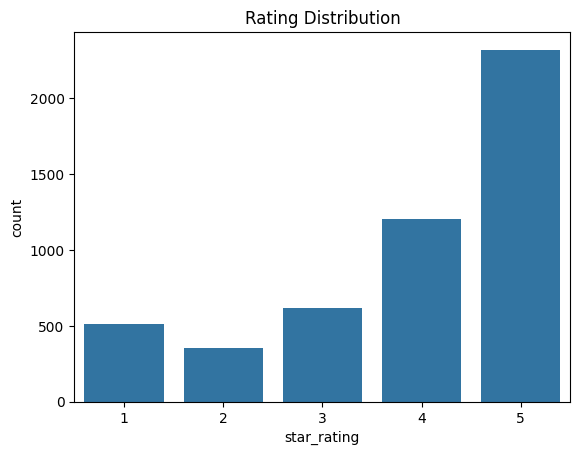

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='star_rating', data=df)
plt.title("Rating Distribution")
plt.show()

In [37]:
print(df['star_rating'].value_counts())
print("\n\nPercentage of each rating Distribution : \n" ,df['star_rating'].value_counts(normalize=True) * 100)

star_rating
5    2319
4    1202
3     615
1     512
2     352
Name: count, dtype: int64


Percentage of each rating Distribution : 
 star_rating
5    46.38
4    24.04
3    12.30
1    10.24
2     7.04
Name: proportion, dtype: float64


Imbalance Ratio of the Max and Min 

In [39]:
counts = df["star_rating"].value_counts()
imbalance_ratio = counts.max() / counts.min()
print(imbalance_ratio)

6.588068181818182


Since the ratio > 5 --> imbalanced Dataset  

In [40]:
df['review_id'].unique

<bound method Series.unique of 0          1
1          2
2          3
3          4
4          5
        ... 
4995    4996
4996    4997
4997    4998
4998    4999
4999    5000
Name: review_id, Length: 5000, dtype: int64>

In [41]:
duplicate_ids = df['review_id'].duplicated().sum()
print(f"Duplicate review_ids: {duplicate_ids}")

Duplicate review_ids: 0


In [32]:
df['review_length_char'] = df['review_text'].astype(str).apply(len)
df['review_length_word'] = df['review_text'].astype(str).apply(lambda x: len(x.split()))
avg_lengths = df.groupby('product_category')[['review_length_char', 'review_length_word']].mean()

print(avg_lengths)

                    review_length_char  review_length_word
product_category                                          
Bathroom                    103.365446           16.042197
Bedroom Furniture           103.279163           16.436846
Kitchen Appliances           99.191540           15.831604
Living Room                  99.584936           15.846154


In [44]:
from collections import Counter

all_text = " ".join(df['review_text'].astype(str))

words = all_text.split()

word_counts = Counter(words)

top_10_words = word_counts.most_common(10)

for word in top_10_words:
    print(f'{word}')

('The', 2739)
('and', 2443)
('the', 1683)
('is', 1335)
('my', 1295)
('arrived', 843)
('but', 841)
('I', 817)
('to', 775)
('was', 724)


In [47]:
top_50_words = word_counts.most_common(50)
for word in top_50_words:
    print(f'{word}')

('The', 2739)
('and', 2443)
('the', 1683)
('is', 1335)
('my', 1295)
('arrived', 843)
('but', 841)
('I', 817)
('to', 775)
('was', 724)
('as', 720)
('product.', 705)
('easy', 683)
('it.', 669)
('a', 647)
('made', 628)
('well', 598)
('at', 595)
('quality.', 519)
('works', 504)
('LED', 500)
('THE', 496)
('on', 455)
('has', 452)
('working', 425)
('https://fakeurl.com/ref123', 420)
('Set', 418)
('exactly', 394)
('love', 389)
('in', 385)
('set', 381)
('this', 375)
('My', 374)
('again.', 373)
('Very', 370)
('Lamp', 364)
('great', 362)
('Works', 328)
('perfectly', 328)
('time.', 328)
('Would', 328)
('buy', 328)
('gift', 327)
('recipient', 327)
('loved', 327)
('Excellent', 327)
('build', 327)
('!!!!!!', 326)
('5', 325)
('exceeded', 324)


Q)Identify the top 10 most frequent words across all reviews (before cleaning). What do you notice?
  The top 10 most frequent Words are stop words , even in the top 50 most frequent words "Stop words" have dominant numbers followed by few product names and items. 
  Case-sensitive Duplicates,HTML tags , puncutation marks and numerics   

Q)Identify the top 10 most frequent words across all reviews (before cleaning). What do you notice?
  The top 10 most frequent Words are stop words , even in the top 50 most frequent words "Stop words" have dominant numbers followed by few product names and items. 
  Case-sensitive Duplicates,HTML tags , puncutation marks and numerics   

Checking for Seasonal trends on reviews per month

In [49]:
df['review_date'] = pd.to_datetime(df['review_date'],errors='coerce')
df['review_date']

0      2024-02-08
1      2023-09-11
2      2023-07-03
3      2023-06-30
4      2024-09-23
          ...    
4995   2024-05-01
4996   2023-06-09
4997   2023-07-15
4998   2024-12-18
4999   2023-04-06
Name: review_date, Length: 5000, dtype: datetime64[us]

In [51]:
df['year_month'] = df['review_date'].dt.to_period('M')

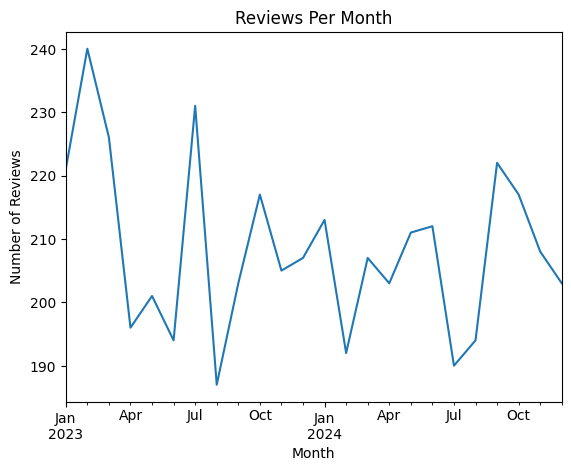

In [52]:
monthly_reviews = df.groupby('year_month').size()

plt.figure()
monthly_reviews.plot()
plt.xlabel("Month")
plt.ylabel("Number of Reviews")
plt.title("Reviews Per Month")
plt.show()

In [58]:
print(monthly_reviews)
print("Avg reviews per month :",monthly_reviews.mean())
print("Standard Deviation of Monthly Reviews :" , monthly_reviews.std())

year_month
2023-01    221
2023-02    240
2023-03    226
2023-04    196
2023-05    201
2023-06    194
2023-07    231
2023-08    187
2023-09    203
2023-10    217
2023-11    205
2023-12    207
2024-01    213
2024-02    192
2024-03    207
2024-04    203
2024-05    211
2024-06    212
2024-07    190
2024-08    194
2024-09    222
2024-10    217
2024-11    208
2024-12    203
Freq: M, dtype: int64
Avg reviews per month : 208.33333333333334
Standard Deviation of Monthly Reviews : 13.421807908632573


The Avg no.of reviews per months is 208+ 13 or 208-14 
which doesn't show any Strong seasonality 

In [60]:
cor = monthly_reviews.std()/monthly_reviews.mean()
print(cor)

0.06442467796143635


Since the Co-efficient of Variation is < 0.1 --> it indicates that the data is very stable 

In [64]:
df['word_count'] = df['review_text'].apply(lambda x: len(str(x).split()))

df.groupby('product_category')['word_count'].describe()

,count,mean,std,min,25%,50%,75%,max
product_category,,,,,,,,
Bathroom,1256.0,16.042197,1.519269,12.0,15.0,16.0,17.0,21.0
Bedroom Furniture,1243.0,16.436846,1.392929,13.0,16.0,16.0,17.0,21.0
Kitchen Appliances,1253.0,15.831604,1.356404,13.0,15.0,16.0,16.0,20.0
Living Room,1248.0,15.846154,1.466127,12.0,15.0,16.0,17.0,21.0
